In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

In [4]:
from src.pdf_reader import extract_text_from_pdf

text = extract_text_from_pdf("../data/raw/book.pdf")

print(text[:2000])


PRAISE FOR
A COUNTRY DOCTOR’S NOTEBOOK
“This book has a freshness and liveliness … an epic quality because of the background 
Russia’s vastness, the great distances, the weight of the ignorance, the need.”
—DORIS LESSI
“These straightforward yet extraordinary sketches gain their strength from also being th
account of a young man’s growth. One begins to see that he became a novelist not becau
he had material but because he was storing up passion and temperament.”
—V.S. PRITCHETT, NEW STATESM
“Stories as keen and bright as a scalpel … Courage shines from every angle of th
profoundly human collection by the greatest of modern Russian writers.”
—SUNDAY TIM
“Bulgakov casts a wonderfully wry, self-deprecating humour. His compassion for huma
folly is unfailing … These stories stand testament both to human resilience and 
remarkable literary talent.”
—THE INDEPENDE

A COUNTRY DOCTOR’S NOTEBOOK
MIKHAIL BULGAKOV (1891–1940) was born in Kiev, one of seven children born to a
university lecturer a

In [5]:
from src.pdf_reader import extract_text_from_pdf
from src.text_processor import process_text

text = extract_text_from_pdf("../data/raw/book.pdf")

tokens = process_text(text)

tokens[:20]

[{'word': 'praise', 'lemma': 'praise', 'pos': 'VERB', 'is_stop': False},
 {'word': 'for', 'lemma': 'for', 'pos': 'ADP', 'is_stop': True},
 {'word': 'a', 'lemma': 'a', 'pos': 'DET', 'is_stop': True},
 {'word': 'country', 'lemma': 'country', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'doctor', 'lemma': 'doctor', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'notebook', 'lemma': 'notebook', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'this', 'lemma': 'this', 'pos': 'DET', 'is_stop': True},
 {'word': 'book', 'lemma': 'book', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'has', 'lemma': 'have', 'pos': 'VERB', 'is_stop': True},
 {'word': 'a', 'lemma': 'a', 'pos': 'DET', 'is_stop': True},
 {'word': 'freshness', 'lemma': 'freshness', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'and', 'lemma': 'and', 'pos': 'CCONJ', 'is_stop': True},
 {'word': 'liveliness',
  'lemma': 'liveliness',
  'pos': 'NOUN',
  'is_stop': False},
 {'word': 'an', 'lemma': 'an', 'pos': 'DET', 'is_stop': True},
 {'word': 'epic'

In [6]:
len(tokens)

47860

In [22]:
from src.vocab_builder import build_vocabulary

vocab_df = build_vocabulary(tokens, min_frequency=2)
vocab_df.head(20)

,lemma,pos,frequency
0,say,VERB,173
1,come,VERB,145
2,woman,NOUN,126
3,doctor,NOUN,120
4,eye,NOUN,112
5,time,NOUN,105
6,look,VERB,94
7,feel,VERB,91
8,think,VERB,91
9,man,NOUN,82


In [23]:
vocab_df.shape

(2383, 3)

In [24]:
vocab_df.sample(20)

,lemma,pos,frequency
1587,battle,NOUN,2
2282,tip,NOUN,2
1166,chancre,NOUN,3
902,cockerel,NOUN,4
1548,abyss,NOUN,2
1610,branch,NOUN,2
567,vision,NOUN,7
2291,trample,VERB,2
1692,count,NOUN,2
1758,dos,NOUN,2


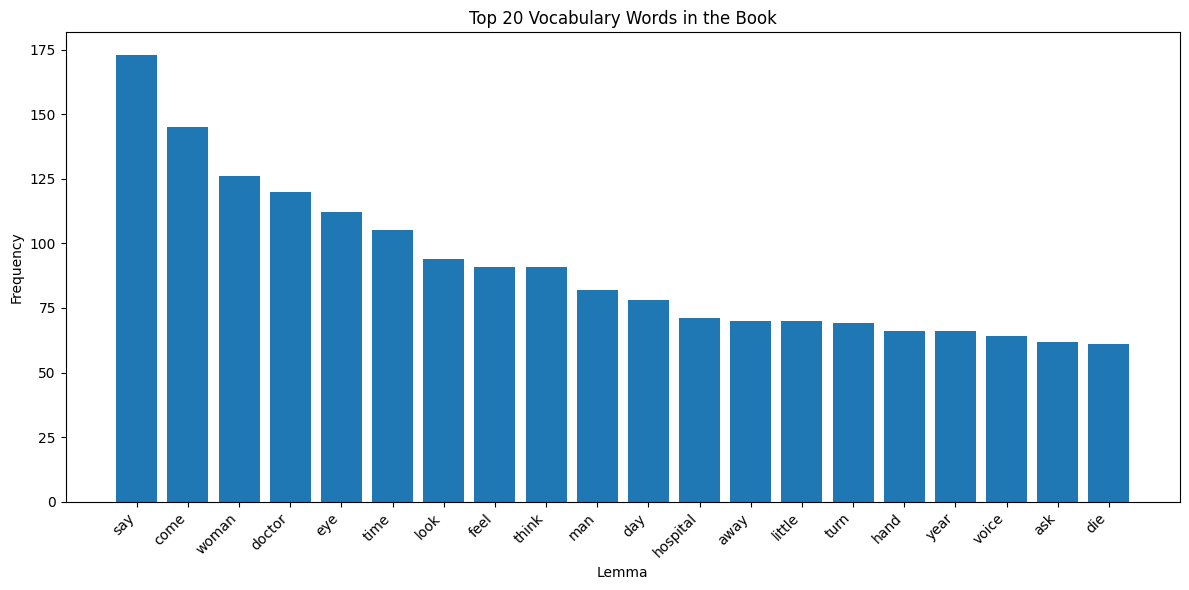

In [25]:
import matplotlib.pyplot as plt

top_n = 20
top_vocab = vocab_df.head(top_n)

plt.figure(figsize=(12, 6))
plt.bar(top_vocab["lemma"], top_vocab["frequency"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Lemma")
plt.ylabel("Frequency")
plt.title("Top 20 Vocabulary Words in the Book")
plt.tight_layout()
plt.show()

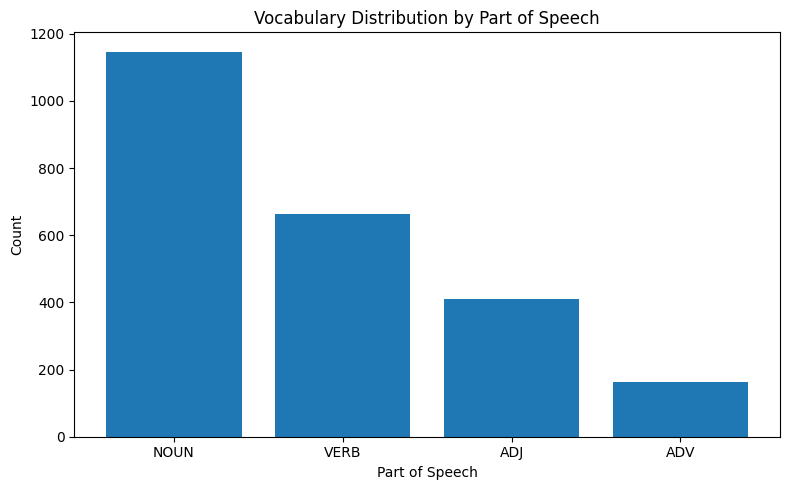

In [26]:
pos_counts = vocab_df["pos"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(pos_counts.index, pos_counts.values)
plt.xlabel("Part of Speech")
plt.ylabel("Count")
plt.title("Vocabulary Distribution by Part of Speech")
plt.tight_layout()
plt.show()

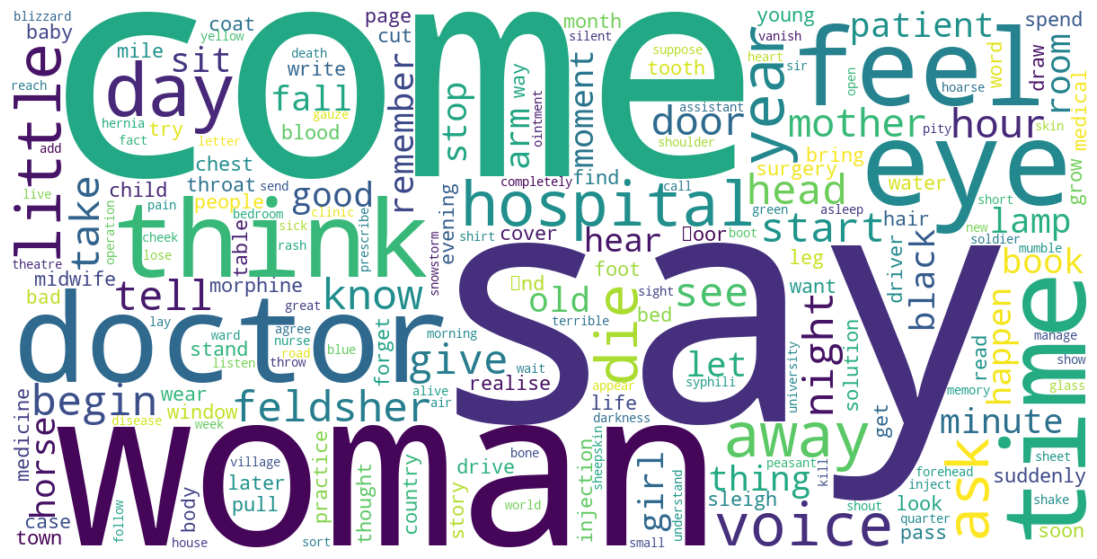

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

freq_dict = dict(zip(vocab_df["lemma"], vocab_df["frequency"]))

wordcloud = WordCloud(width=1200, height=600, background_color="white").generate_from_frequencies(freq_dict)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [28]:
vocab_df["frequency"].describe()

count    2383.000000
mean        6.759966
std        11.196300
min         2.000000
25%         2.000000
50%         3.000000
75%         6.000000
max       173.000000
Name: frequency, dtype: float64

In [29]:
vocab_df["pos"].value_counts()


pos
NOUN    1147
VERB     664
ADJ      410
ADV      162
Name: count, dtype: int64

In [34]:
from src.example_extractor import add_example_sentences

vocab_with_examples = add_example_sentences(vocab_df, text)
vocab_with_examples.head(5)

,lemma,pos,frequency,example_sentence
0,say,VERB,173,There is nothing I can say about my toes—they ...
1,come,VERB,145,This morning we set\n\noʃ at seven in the morn...
2,woman,NOUN,126,‘Leopold Leopoldovich sometimes had ɹfty in he...
3,doctor,NOUN,120,PRAISE FOR\nA COUNTRY DOCTOR’S NOTEBOOK\n“This...
4,eye,NOUN,112,Title.\n PG3476.B78A2 2013\n 891.78’4203–dc2...


In [33]:
vocab_with_examples[["lemma", "frequency", "example_sentence"]].head(20)

,lemma,frequency,example_sentence
0,say,173,There is nothing I can say about my toes—they ...
1,come,145,This morning we set\n\noʃ at seven in the morn...
2,woman,126,‘Leopold Leopoldovich sometimes had ɹfty in he...
3,doctor,120,PRAISE FOR\nA COUNTRY DOCTOR’S NOTEBOOK\n“This...
4,eye,112,Title.\n PG3476.B78A2 2013\n 891.78’4203–dc2...
5,time,105,"In 1919 he left medicine to write\nfull-time, ..."
6,look,94,And as you\ndie a slow death there’s nothing t...
7,feel,91,"And more to the point, what will a hernia\npat..."
8,think,91,Just think … I actually had to put up for the ...
9,man,82,PRAISE FOR\nA COUNTRY DOCTOR’S NOTEBOOK\n“This...


In [35]:
vocab_with_examples.sample(10)

,lemma,pos,frequency,example_sentence
1085,travel,NOUN,4,It hung in my bedroom in Muryovo and then went...
2064,peel,VERB,2,I shuddered and glanced round miserably at the...
2264,tandem,NOUN,2,"I’ve a couple of fast horses,\nharnessed in ta..."
92,midwife,NOUN,28,"My feldsher* was called Demyan Lukich, the mid..."
285,version,NOUN,12,These date from Bulgakov’s richly productive p...
39,patient,NOUN,44,Although his patients are his contemporaries a...
2291,trample,VERB,2,Indeed so nearly exactly twenty-four hours tha...
1173,close,ADJ,3,"‘Tell him about the sugar,\nPelagea Ivanovna!’..."
2353,wheel,VERB,2,"One wheel got stuck in a ditch, the other swun..."
1014,picture,NOUN,4,As I thought this I pictured the\nmother’s eyes.


In [36]:
vocab_with_examples.to_csv("../outputs/vocabulary_with_examples.csv", index=False)